# Metabolic Phenotyping

This notebook identifies data-driven metabolic phenotypes within the prepared NHANES analysis cohort using unsupervised clustering.

Clustering is performed using metabolic and anthropometric measurements only. The CAP measurement and hepatic steatosis outcome are not included in the clustering process, allowing phenotypes to be identified independently of the study outcome.

## Loading the analysis cohort and selecting clustering variables

The prepared analysis cohort from `01_data_preparation.ipynb` is loaded from `analysis_cohort.csv`.

Variables representing several metabolic domains are selected for clustering: BMI and waist circumference represent general and central adiposity; systolic and diastolic blood pressure represent cardiovascular status; HDL and triglycerides represent lipid metabolism; and fasting glucose represents glucose regulation.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_PATH = Path("../data/processed/analysis_cohort.csv")
PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(DATA_PATH)

cluster_features = [
    "bmi",
    "waist_cm",
    "systolic_bp",
    "diastolic_bp",
    "hdl_mg_dl",
    "triglycerides_mg_dl",
    "glucose_mg_dl",
]

print(f"Participants: {len(df):,}")
print(f"Clustering variables: {len(cluster_features)}")

df[cluster_features].describe().T

Participants: 3,270
Clustering variables: 7


,count,mean,std,min,25%,50%,75%,max
bmi,3270.0,29.486911,7.032075,15.400000,24.500000,28.300000,33.175000,65.3
waist_cm,3270.0,99.657370,16.874911,61.100000,87.425000,98.400000,110.400000,169.5
systolic_bp,3270.0,123.435933,18.523845,78.666667,110.000000,120.666667,133.333333,214.0
diastolic_bp,3270.0,74.176198,11.259667,41.333333,66.333333,73.333333,81.333333,126.0
hdl_mg_dl,3270.0,53.376758,15.729180,11.000000,42.000000,51.000000,61.000000,187.0
triglycerides_mg_dl,3270.0,109.311621,95.838413,10.000000,59.250000,88.000000,131.000000,2684.0
glucose_mg_dl,3270.0,112.443425,36.877917,47.000000,96.000000,103.000000,114.000000,451.0


## Standardizing metabolic variables

The selected metabolic variables are measured using different units and numerical scales. Directly applying a distance-based clustering algorithm to the original measurements could therefore cause variables with larger numerical ranges to have greater influence on the resulting clusters.

The variables are standardized using `StandardScaler`, which transforms each variable to have approximately zero mean and unit variance. This places the clustering variables on comparable scales while preserving their relative differences between participants.

In [2]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(df[cluster_features])

X_cluster = pd.DataFrame(
    X_cluster,
    columns=cluster_features,
    index=df.index,
)

X_cluster.describe().round(2)

,bmi,waist_cm,systolic_bp,diastolic_bp,hdl_mg_dl,triglycerides_mg_dl,glucose_mg_dl
count,3270.00,3270.00,3270.00,3270.00,3270.00,3270.00,3270.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.00,-2.29,-2.42,-2.92,-2.69,-1.04,-1.77
25%,-0.71,-0.72,-0.73,-0.70,-0.72,-0.52,-0.45
50%,-0.17,-0.07,-0.15,-0.07,-0.15,-0.22,-0.26
75%,0.52,0.64,0.53,0.64,0.48,0.23,0.04
max,5.09,4.14,4.89,4.60,8.50,26.87,9.18


## Determining the number of metabolic phenotypes

K-means clustering requires the number of clusters (`k`) to be specified before fitting the final model. Candidate solutions from one to six clusters are therefore compared using the elbow method and silhouette analysis.

The elbow method examines within-cluster inertia, with a substantial reduction followed by diminishing improvements suggesting a suitable number of clusters. Silhouette analysis evaluates how well participants are separated between clusters, with higher values indicating greater separation.

Silhouette scores require at least two clusters and are therefore calculated only for `k = 2` through `k = 6`.

,k,inertia,silhouette
0,1,22890.000000,NaN
1,2,17592.944086,0.237453
2,3,15502.399112,0.205831
3,4,13521.305541,0.221600
4,5,12183.166078,0.187199
5,6,11142.422312,0.189620


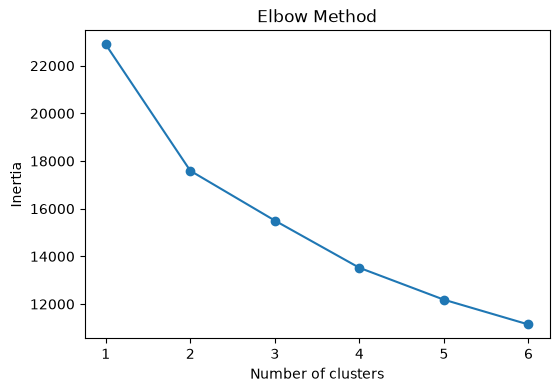

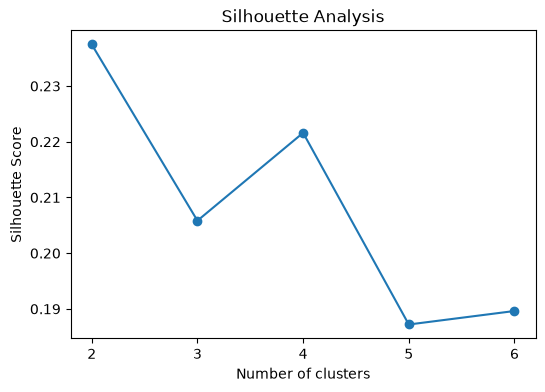

In [3]:
# Compare possible numbers of clusters

results = []

for k in range(1, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = model.fit_predict(X_cluster)

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": (
            silhouette_score(X_cluster, labels)
            if k > 1 else None
        ),
    })

cluster_results = pd.DataFrame(results)

display(cluster_results)

# Elbow method: k = 1–6
plt.figure(figsize=(6, 4))
plt.plot(
    cluster_results["k"],
    cluster_results["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 7))
plt.show()

# Silhouette: only defined for k >= 2
plt.figure(figsize=(6, 4))
plt.plot(
    cluster_results.loc[cluster_results["k"] >= 2, "k"],
    cluster_results.loc[cluster_results["k"] >= 2, "silhouette"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.xticks(range(2, 7))
plt.show()

The elbow plot shows the largest reduction in inertia between one and two clusters, after which improvements become progressively smaller. The two-cluster solution also produces the highest silhouette score among the candidate solutions.

Based on the combination of the elbow and silhouette results, `k = 2` is selected for the final K-means model.

## Identifying and characterizing metabolic phenotypes

The final K-means model is fitted using two clusters. Each participant is assigned to the cluster whose centroid is closest to their standardized metabolic profile.

Cluster numbers are arbitrary and do not have an inherent clinical meaning. The resulting clusters are therefore characterized after fitting by comparing the original, unstandardized metabolic measurements across clusters.

Mean BMI, waist circumference, blood pressure, HDL cholesterol, triglycerides and fasting glucose are compared between the two groups. These patterns are used to describe and interpret the metabolic phenotype represented by each cluster. Phenotype labels are assigned only after examining the observed cluster characteristics.

In [4]:
# Fit final two-cluster K-means model

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20,
)

df["cluster"] = kmeans.fit_predict(X_cluster)

# Compare cluster sizes and metabolic characteristics
cluster_sizes = df["cluster"].value_counts().sort_index()

cluster_profiles = (
    df.groupby("cluster")[cluster_features]
    .mean()
    .round(1)
)

print("Cluster sizes:")
print(cluster_sizes)

print("\nMean metabolic characteristics:")
display(cluster_profiles)

Cluster sizes:
cluster
0    1784
1    1486
Name: count, dtype: int64

Mean metabolic characteristics:


,bmi,waist_cm,systolic_bp,diastolic_bp,hdl_mg_dl,triglycerides_mg_dl,glucose_mg_dl
cluster,,,,,,,
0,25.3,88.7,117.5,69.7,59.4,82.7,101.7
1,34.5,112.8,130.6,79.6,46.1,141.3,125.4


### Interpretation of the metabolic phenotypes

The two-cluster solution identified two broad metabolic profiles among the 3,270 participants. Although the two-cluster solution was supported by the elbow and silhouette comparisons, the silhouette score indicates that separation between the groups is modest. The phenotypes should therefore be interpreted as broad data-driven metabolic profiles rather than sharply separated clinical subgroups.

**Cluster 0 (n = 1,784)** was characterized by lower mean BMI, waist circumference, blood pressure, triglycerides and fasting glucose, together with higher mean HDL cholesterol. This cluster is therefore described as the **lower metabolic-risk phenotype**.

**Cluster 1 (n = 1,486)** showed the opposite pattern, with higher mean BMI, waist circumference, blood pressure, triglycerides and fasting glucose, together with lower mean HDL cholesterol. This cluster is therefore described as the **higher metabolic-risk phenotype**.

These phenotype labels are descriptive rather than diagnostic. Importantly, CAP and hepatic steatosis status were not included in the clustering process. The phenotypes were identified solely from the selected metabolic measurements, independently of the study outcome.

The resulting phenotype assignments will subsequently be used to examine whether hepatic steatosis screening performance and influential predictors differ between metabolic profiles.

In [5]:
# Add descriptive phenotype labels
phenotype_map = {
    0: "Lower metabolic-risk",
    1: "Higher metabolic-risk",
}

df["metabolic_phenotype"] = df["cluster"].map(phenotype_map)

# Save cohort with cluster assignments
output_path = PROCESSED_DIR / "clustered_cohort.csv"
df.to_csv(output_path, index=False)

print(df["metabolic_phenotype"].value_counts())
print(f"\nSaved to: {output_path}")

metabolic_phenotype
Lower metabolic-risk     1784
Higher metabolic-risk    1486
Name: count, dtype: int64

Saved to: ../data/processed/clustered_cohort.csv


## Saving phenotype assignments

The descriptive phenotype labels are mapped to the numerical K-means cluster assignments and added to the analysis cohort.

Both the original numerical cluster assignment and the descriptive metabolic phenotype are retained. The resulting dataset is saved as `clustered_cohort.csv` for use in the subsequent predictive modeling and phenotype-specific evaluation stages.

## References

1. MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability*, 1, 281–297.

2. Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7